In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import sys
import pyabc
import seaborn as sns

import healpy as hp
from scipy.special import sph_harm
import fitsio
import skyproj
from astropy.coordinates import SkyCoord, Angle
import astropy.units as u

sys.path.insert(0, '/home/aew492/lss-dipoles/code')
import tools
import dipole
import multipoles
import generate_mocks as gm
from abc_for_qso import get_catalog_info

In [3]:
plt.rcParams["font.family"] = "serif"

## quasar catalogs

In [4]:
blim = 30
nside_hi = 64

In [5]:
# expected dipole direction
cmb_dipdir = dipole.cmb_dipole()[1]

#### sample names and labels

In [6]:
# store results in a dictionary
labels = {
    'quaia_G20.0' : 'Quaia G20.0',
    'quaia_G20.0_orig' : 'Quaia G20.0 (no zodi)',
    'quaia_G20.5' : 'Quaia G20.5',
    'quaia_G20.5_orig' : 'Quaia G20.5 (no zodi)',
    'quaia_G20.0_zsplit2bin0' : 'Quaia G20.0 z<1.5',
    'quaia_G20.0_zsplit2bin1' : 'Quaia G20.0 z>1.5',
    'catwise' : 'CatWISE',
    'catwise_orig' : 'CatWISE (no zodi)',
    'catwise_elatcorr' : 'S21'
}

## ABC results

In [7]:
resdir = '/scratch/aew492/lss-dipoles_results/results'
nside = 2

### `dipole_amp` as only free parameter

In [8]:
def get_abc_results_dipole_only(fn, xticks=None, title=None, plot=True):

    res = np.load(fn, allow_pickle=True).item()
    history = res['history']
    prior = res['prior']
    posterior = res['posterior']
    selfunc = res['selfunc']
    expected_dipamp = res['expected_dipole_amp']
    print(f"expected dipole_amp = {expected_dipamp}")
    
    # quantiles
    df, w = posterior
    q_dipamp = tools.quantile(df['dipole_amp'], [0.16, 0.5, 0.84], weights=w)

    # calculate the sigma discrepancy: ****check with Kate and Hogg: is this the right way to do this?
    # z score is z = (x_0 - \mu) / \sigma , where x_0 is the null hypothesis, \mu is mean (or MAP? or median?)
    #    and \sigma = std. of the posterior
    
    # how different is the mean from the median?
    print(f"mean dipole_amp = {pyabc.weighted_statistics.weighted_mean(df['dipole_amp'], w):.4f}")
    print(f"median dipole_amp = {q_dipamp[1]:.4f}")
    mu = q_dipamp[1]
    
    # standard deviation
    sigma = pyabc.weighted_statistics.weighted_std(df['dipole_amp'], w)
    print(f"std dipole_amp = {sigma:.4f}")

    relamp = np.array(q_dipamp) / expected_dipamp
    
    # z score
    z = (expected_dipamp - mu) / sigma
    print(f"z score = {z:.4f}")

    # plot (copied and adjusted from the pyabc.visualization source code)
    if plot:
        par_id = [x for x in prior.keys()][0]
        fig, ax = plt.subplots(figsize=(5,4), tight_layout=True)
        label = r'Dipole amplitude in CMB dir. $|\vec D|$'
        
        df, w = posterior
        
        # quantiles?
        q = tools.quantile(df[par_id], [0.16, 0.5, 0.84], weights=w)
        
        # diagonal
        ax.axvline(q[1], c='k', alpha=0.4, ls='-', label='Median')
        ax.axvspan(q[0], q[2], color='k', alpha=0.05)
        ax.axhline(0., c='k', alpha=0.5, lw=0.5)
        ax.axvline(expected_dipamp, c='crimson', alpha=0.8, lw=1.5, label='Expected')
        ax.legend()
        ax.grid(alpha=0.5, lw=0.5)
        ax.set_xlim(prior[par_id].args[0], prior[par_id].args[0] + prior[par_id].args[1])
        if xticks is not None:
            ax.set_xticks(xticks)
        ax.axvline(0., c='k', alpha=0.5, lw=0.5)
        
        x, pdf = tools.get_kde_1d([df, w], prior, par_id, numx=500)
        # normalize the pdf
        pdf /= np.trapz(pdf, x=x)
        ax.plot(x, pdf, c='k', alpha=0.9, lw=1.5)
        
        ax.set_xlabel(label)
        ax.set_ylabel(f'Posterior')
    
        if title is not None:
            ax.set_title(title)
    
        # update all font sizes in this ax
        for text in ax.findobj(match=plt.Text):
            text.set_fontsize(12)

        return q_dipamp, relamp, z, res, ax

    else:
        return q_dipamp, relamp, z, res

In [9]:
def plot_convergence(res, title=None):
    history = res['history']
    fig, ax = plt.subplots(figsize=(7,4), tight_layout=True)
    norm = mpl.colors.Normalize(vmin=0, vmax=history.max_t)
    smap = mpl.cm.ScalarMappable(norm=norm, cmap='jet')
    for j in range(history.max_t + 1):
        alpha = ((j + 1) / (history.max_t + 1))**(1/2)
        pyabc.visualization.plot_kde_1d_highlevel(history, 'dipole_amp', t=j, ax=ax, color=smap.to_rgba(j), alpha=alpha)
    ax.grid(alpha=0.5, lw=0.5)
    ax.axvline(0., c='k', alpha=0.5, lw=0.5)
    ax.axhline(0., c='k', alpha=0.5, lw=0.5)
    ax.axvline(res['expected_dipole_amp'], c='k', ls='--', alpha=0.5)
    if title is not None:
        fig.suptitle(f'Convergence: {sample_name}')
    fig.colorbar(smap, ax=ax, label='Generation')

In [10]:
abc_amp_res = {
    'quantiles' : {},
    'relamps' : {},
    'zscores' : {},
    'ress' : {}
}

In [11]:
nmocks = 500
niters = 15


quaia_G20.0:
expected dipole_amp = 0.0052
mean dipole_amp = 0.0087
median dipole_amp = 0.0086
std dipole_amp = 0.0029
z score = -1.1711

quaia_G20.0_orig:
expected dipole_amp = 0.0052
mean dipole_amp = 0.0096
median dipole_amp = 0.0096
std dipole_amp = 0.0030
z score = -1.4646

quaia_G20.5:
expected dipole_amp = 0.0047
mean dipole_amp = 0.0091
median dipole_amp = 0.0090
std dipole_amp = 0.0023
z score = -1.9194

quaia_G20.5_orig:
expected dipole_amp = 0.0047
mean dipole_amp = 0.0129
median dipole_amp = 0.0127
std dipole_amp = 0.0024
z score = -3.3323

quaia_G20.0_zsplit2bin0:
expected dipole_amp = 0.005
mean dipole_amp = 0.0126
median dipole_amp = 0.0126
std dipole_amp = 0.0037
z score = -2.0588

quaia_G20.0_zsplit2bin1:
expected dipole_amp = 0.0055
mean dipole_amp = 0.0111
median dipole_amp = 0.0111
std dipole_amp = 0.0036
z score = -1.5799

catwise:
expected dipole_amp = 0.0074
mean dipole_amp = 0.0093
median dipole_amp = 0.0092
std dipole_amp = 0.0019
z score = -0.9555

catwise_ori

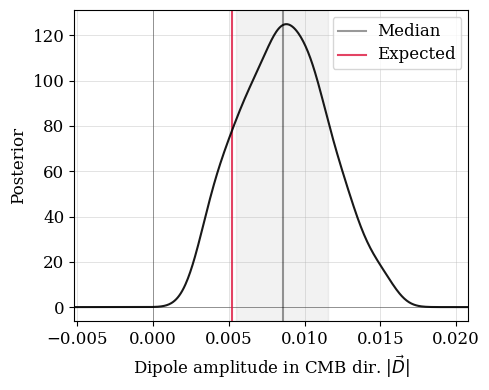

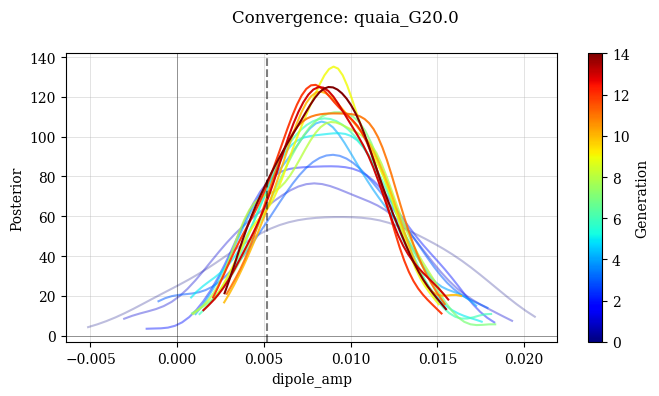

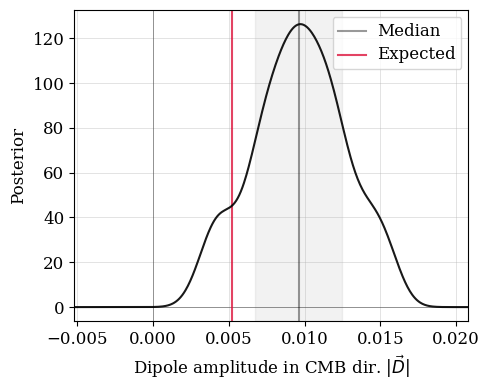

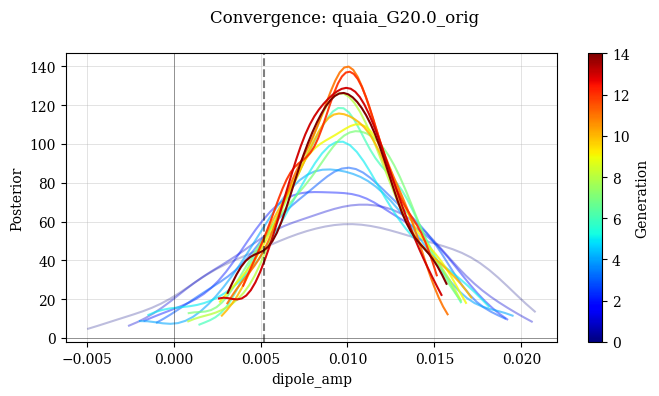

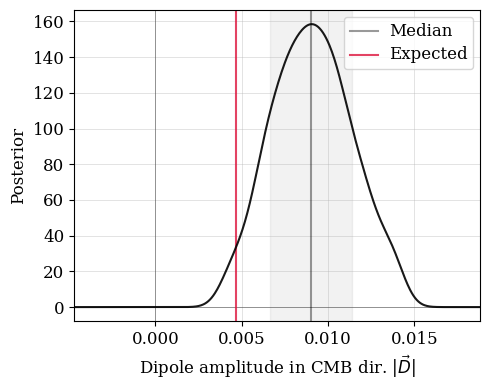

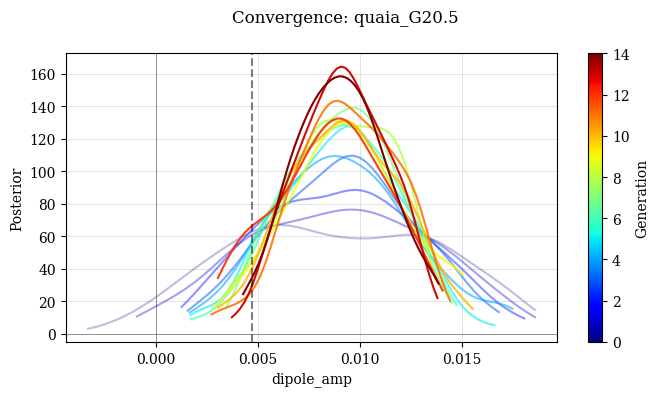

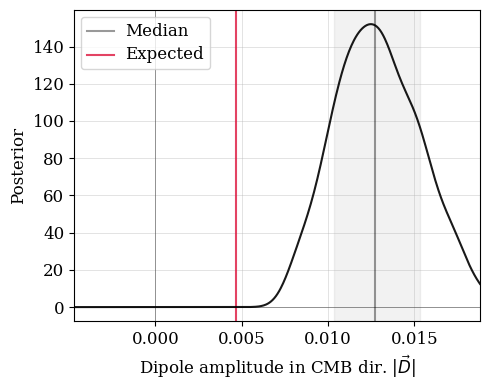

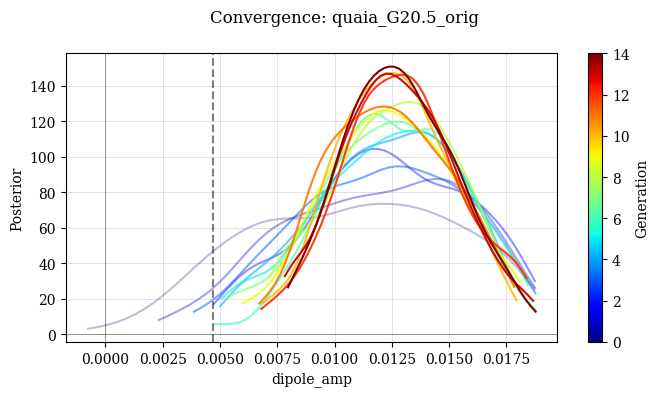

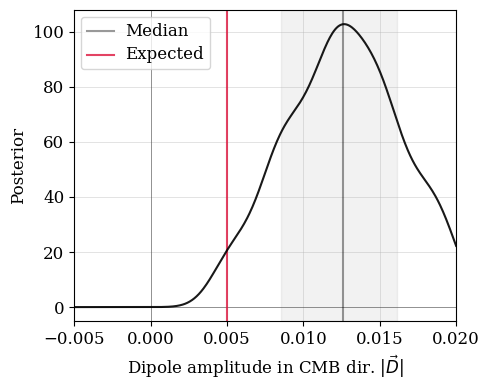

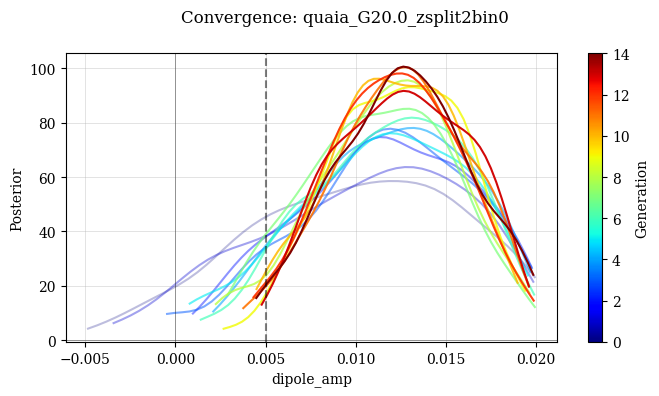

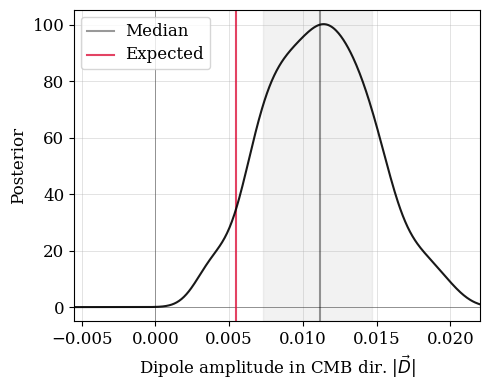

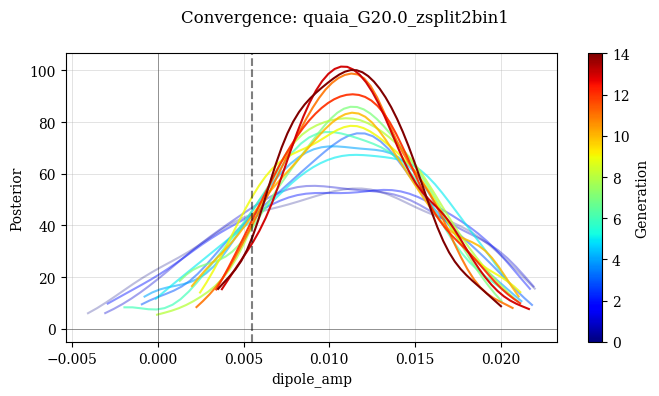

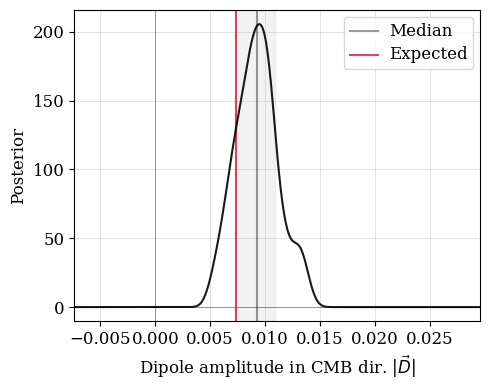

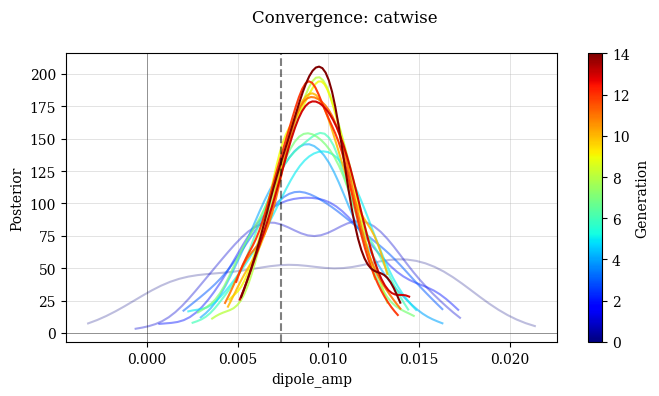

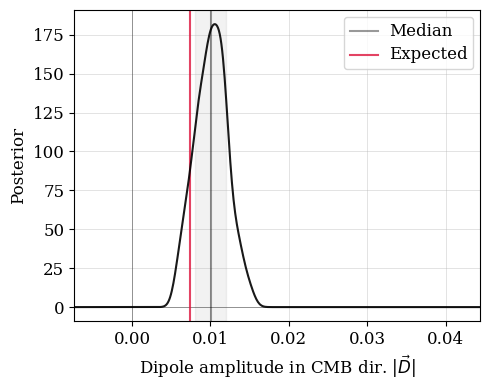

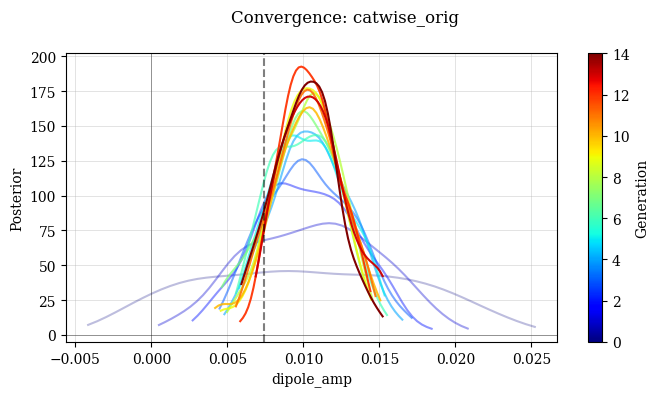

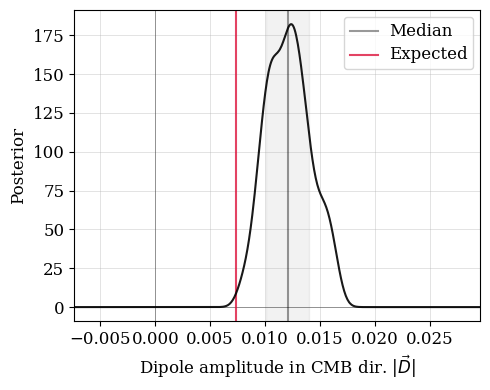

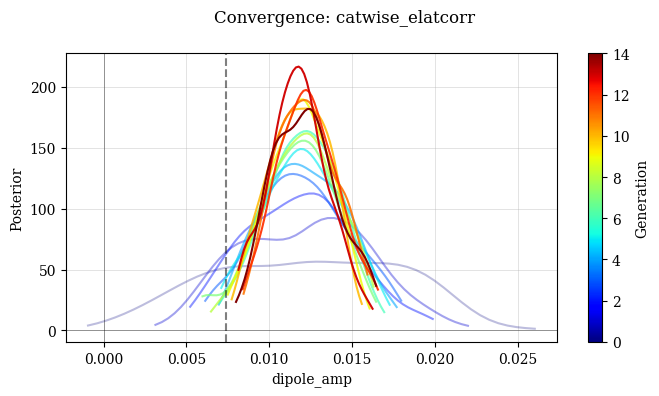

In [12]:
for (sample_name, label) in labels.items():
    print(f"\n{sample_name}:")
    cat_info = get_catalog_info(sample_name)
    base_rate = cat_info['base_rate']
    selfunc_str = cat_info['selfunc_str']
    try:
        q, relamp, z, res, ax = get_abc_results_dipole_only(os.path.join(resdir,
                                f'ABC/{selfunc_str}_dipole_only_nside{nside}_{nmocks}mocks_{niters}iters_base-rate-{base_rate:.4f}',
                                f'results.npy'))
    except FileNotFoundError:
        print(f"no results found for {sample_name} ({selfunc_str} selfunc).")
        continue
    abc_amp_res['quantiles'][sample_name] = q
    abc_amp_res['relamps'][sample_name] = relamp
    abc_amp_res['zscores'][sample_name] = z
    abc_amp_res['ress'][sample_name] = res

    # check out convergence
    plot_convergence(res, title=f"Convergence: {sample_name}")

### free dipole: `dipole_x`, `dipole_y`, `dipole_z`

In [13]:
def get_abc_results_free_dipole(fn, xticks=None, title=None, plot=True):

    res = np.load(fn, allow_pickle=True).item()
    history = res['history']
    prior = res['prior']
    posterior = res['posterior']
    selfunc = res['selfunc']
    expected_dipamp = res['expected_dipole_amp']
    print(f"expected dipole_amp = {expected_dipamp}")

    # quantiles
    df, w = posterior
    par_ids = [x for x in prior.keys()]
    q = np.array([
        tools.quantile(df[par_id], [0.16, 0.5, 0.84], weights=w) for par_id in par_ids
    ])
    # get the inferred dipole from the median posterior
    inferred_dipole_comps = q[:,1]
    dipamp, dipdir = dipole.get_dipole(inferred_dipole_comps)
    print(f"inferred dipole has amplitude {dipamp:.5f} towards (l, b) = ({dipdir.galactic.l.deg:.2f}, " + \
          f"{dipdir.galactic.b.deg:.2f}) deg")

    # proper way to get z score?? how to get uncertainty in inferred dipole amplitude from the uncertainties
    #   in the three individual components? (my lack of error propagation skills haunting me once again..)

    # plot (copied and adjusted from the pyabc.visualization source code)
    if plot:
        # what are the expected dipole components?
        expected_dipole_comps = tools.dipole_dir_to_comps(dipole.cmb_dipole()[1]) * expected_dipamp

        fig, axs = plt.subplots(len(par_ids), len(par_ids), figsize=(9,8), tight_layout=True)
        
        # color things
        cmap = mpl.colormaps['Blues']
        # get one of the colors for the 1D and scatter plots
        c = cmap(0.7)
        
        for i, par_id in enumerate(par_ids):
        
            # diagonal
            ax = axs[i, i]
            ax.axvline(q[i,1], c=c, alpha=0.4, ls='-', label='Median')
            ax.axvspan(q[i,0], q[i,2], color=c, alpha=0.05)
            x, pdf = tools.get_kde_1d(history, prior, par_id, numx=500)
            ax.plot(x, pdf, c=c, alpha=0.9, lw=2)
            ax.set_ylim(0., None)
            ax.grid(alpha=0.5, lw=0.5)
            label = 'Expected' if i == 0 else ''
            ax.axvline(expected_dipole_comps[i], c='crimson', alpha=0.7, lw=2, label=label)
            if i == 0:
                ax.legend()
        
            axs[i,0].set_ylabel(par_id)
            axs[len(par_ids)-1,i].set_xlabel(par_id)
        
            for j in range(0, i):
        
                # lower
                ax = axs[i, j]
                x, y, pdf = tools.get_kde_2d(history, prior, par_ids[j], par_id)
                mesh = ax.pcolormesh(x, y, pdf, shading='auto', cmap=cmap)
        
                # upper
                ax = axs[j, i]
                tools.scatter(history, prior, par_id, par_ids[j], ax, color=c, alpha=0.3, marker='.', s=3)
                ax.grid(alpha=0.5, lw=0.5)
                
        # update all font sizes in the axes
        for ax in axs.flatten():
            for text in ax.findobj(match=plt.Text):
                text.set_fontsize(12)
                
        if title is not None:
            fig.suptitle(title)

        return q, res, dipamp, dipdir, axs

    else:
        return q, res, dipamp, dipdir

In [14]:
abc_free_res = {
    'quantiles' : {},
    'relamps' : {},
    'dirs' : {},
    'ress' : {}
}


quaia_G20.0:
expected dipole_amp = 0.0052
inferred dipole has amplitude 0.01147 towards (l, b) = (291.72, 31.05) deg

quaia_G20.0_orig:
expected dipole_amp = 0.0052
inferred dipole has amplitude 0.01442 towards (l, b) = (314.91, 30.11) deg

quaia_G20.5:
no results found for quaia_G20.5 (quaia_G20.5_zodi selfunc).

quaia_G20.5_orig:
expected dipole_amp = 0.0047
inferred dipole has amplitude 0.01819 towards (l, b) = (338.66, 36.95) deg

quaia_G20.0_zsplit2bin0:
no results found for quaia_G20.0_zsplit2bin0 (quaia_G20.0_zsplit2bin0 selfunc).

quaia_G20.0_zsplit2bin1:
no results found for quaia_G20.0_zsplit2bin1 (quaia_G20.0_zsplit2bin1 selfunc).

catwise:
expected dipole_amp = 0.0074
inferred dipole has amplitude 0.01376 towards (l, b) = (194.69, 31.94) deg

catwise_orig:
expected dipole_amp = 0.0074
inferred dipole has amplitude 0.01293 towards (l, b) = (200.14, 42.33) deg

catwise_elatcorr:
expected dipole_amp = 0.0074
inferred dipole has amplitude 0.01551 towards (l, b) = (238.20, 28.2

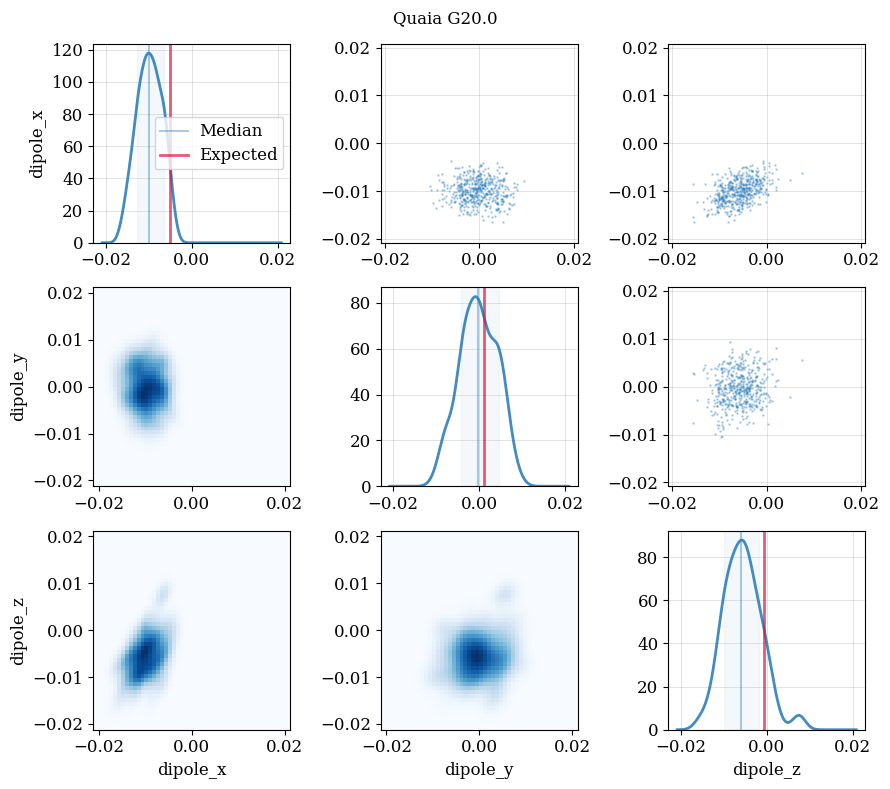

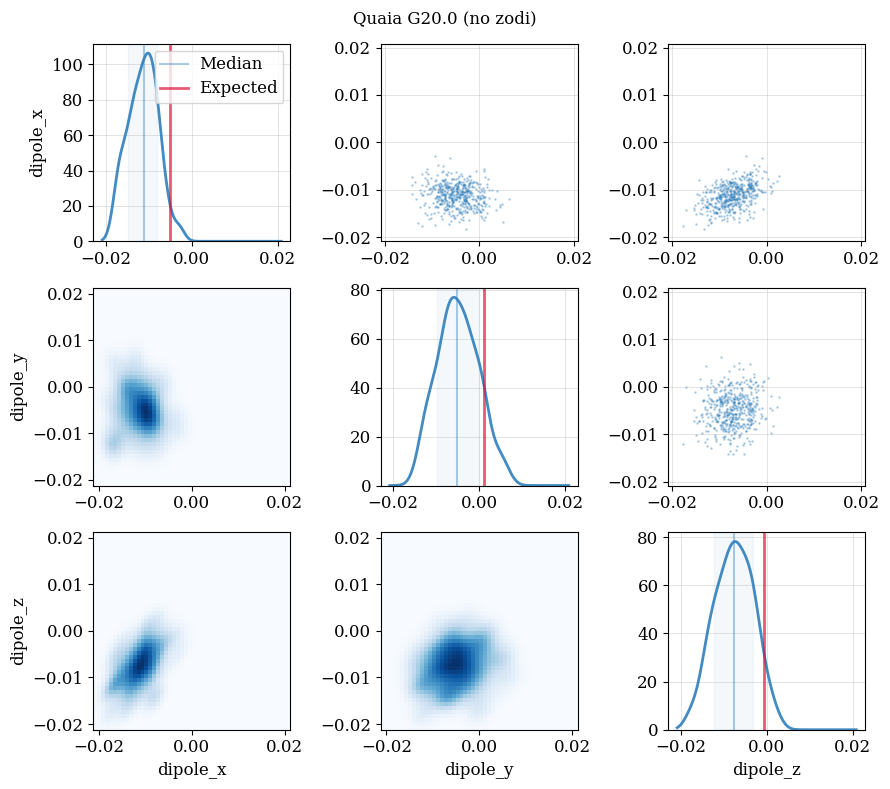

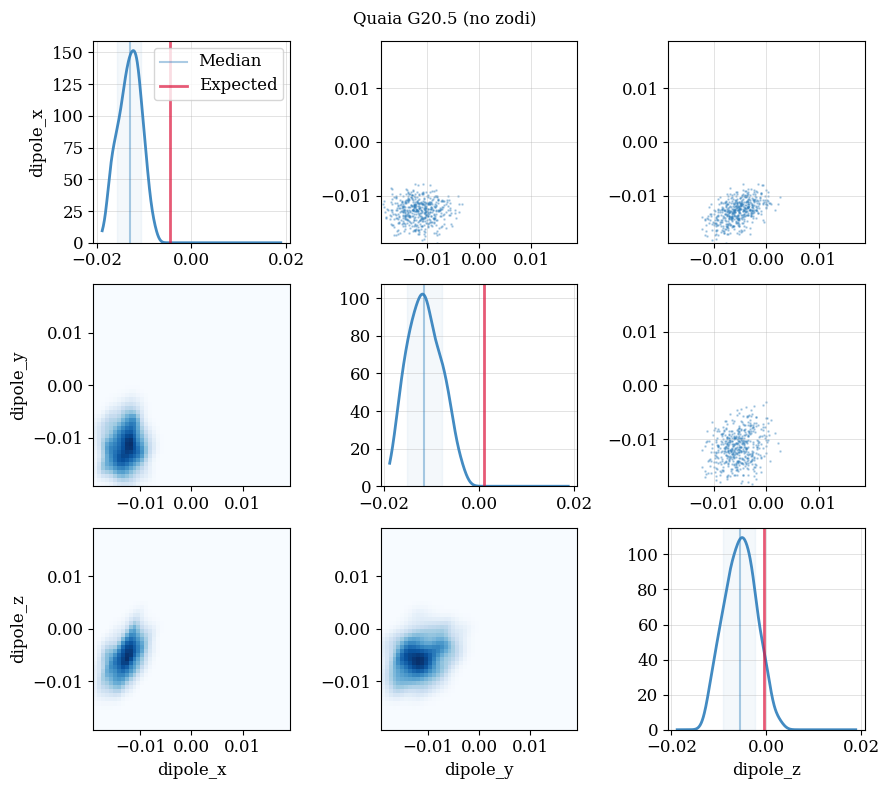

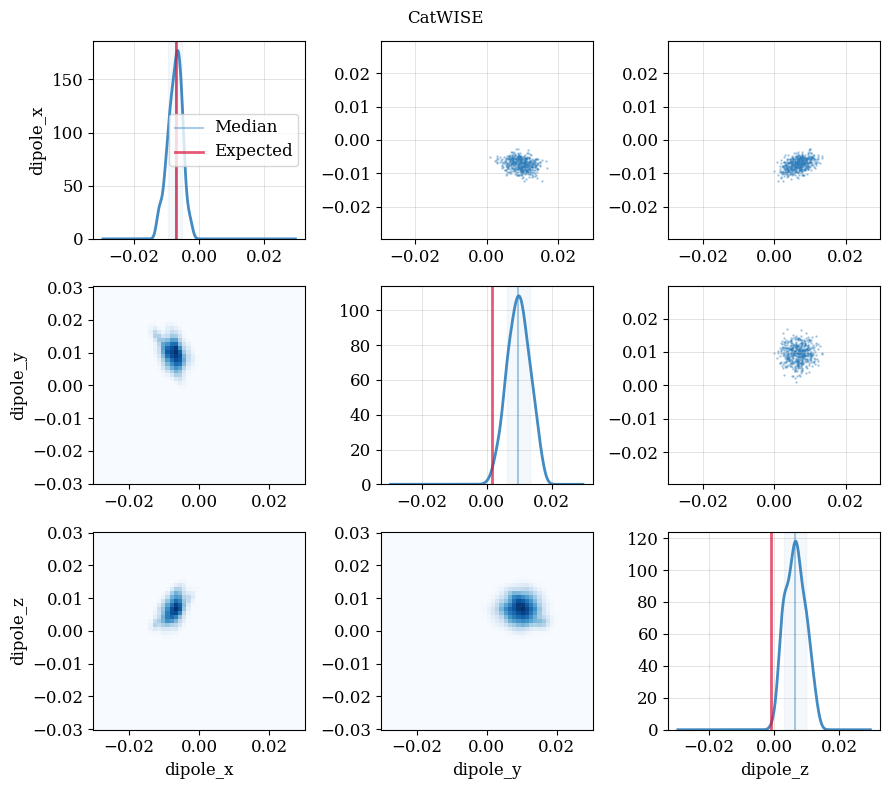

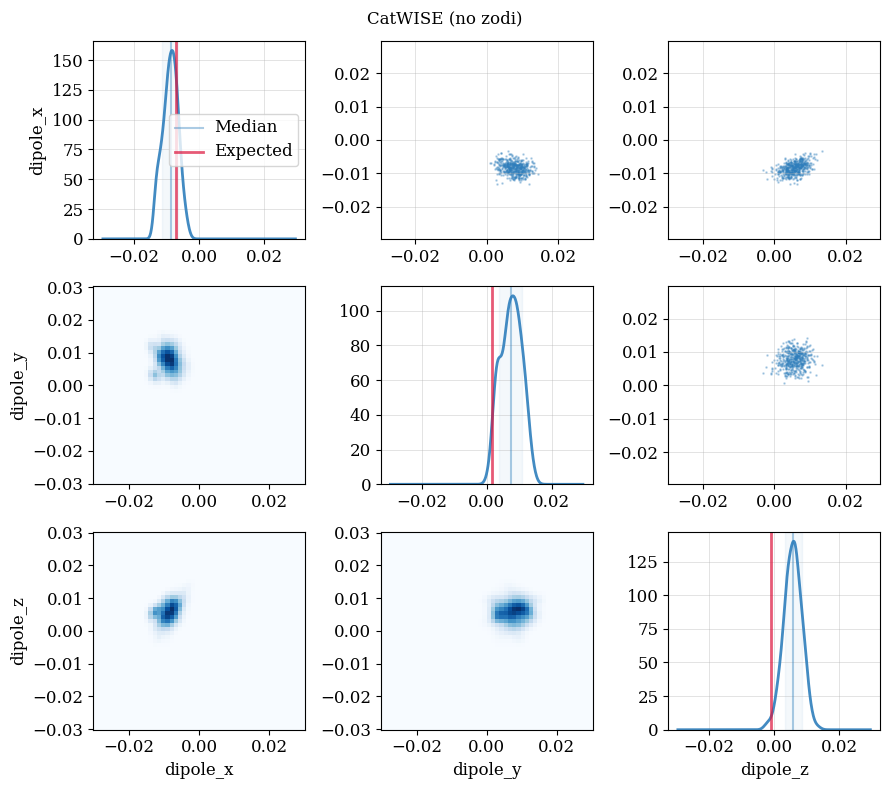

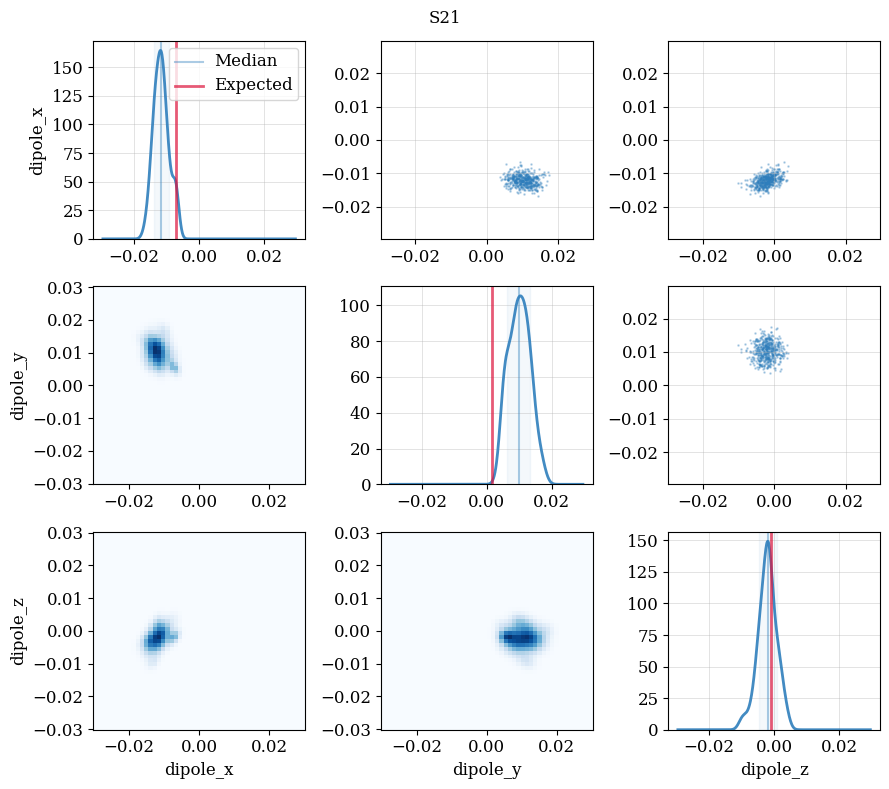

In [15]:
for (sample_name, label) in labels.items():
    print(f"\n{sample_name}:")
    cat_info = get_catalog_info(sample_name)
    base_rate = cat_info['base_rate']
    selfunc_str = cat_info['selfunc_str']
    try:
        q, res, dipamp, dipdir, axs = get_abc_results_free_dipole(os.path.join(resdir,
                                f'ABC/{selfunc_str}_free_dipole_nside{nside}_{nmocks}mocks_{niters}iters_base-rate-{base_rate:.4f}',
                                f'results.npy'), title=label)
    except FileNotFoundError:
        print(f"no results found for {sample_name} ({selfunc_str} selfunc).")
        continue
    abc_free_res['quantiles'][sample_name] = q
    abc_free_res['relamps'][sample_name] = dipamp / cat_info['expected_dipole_amp']
    abc_free_res['dirs'][sample_name] = dipdir
    abc_free_res['ress'][sample_name] = res

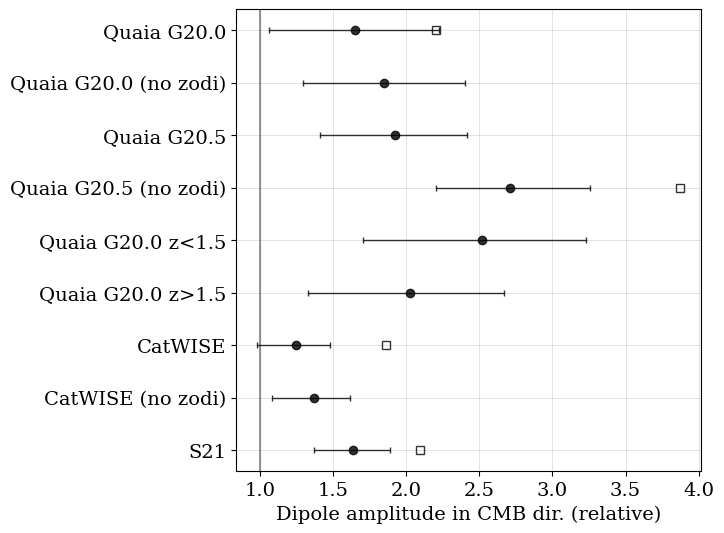

In [17]:
# summary plot
fig, ax = plt.subplots(figsize=(6,6))
cs = plt.get_cmap('tab10').colors

names = list(labels.values())
ylocs = np.arange(len(names))

ax.axvline(1., color='k', alpha=0.4)

for i, (key, label) in enumerate(labels.items()):
    # get the index
    iname = names.index(label)
    
    # amplitude from fixed direction, free amplitude model
    try:
        relamp = abc_amp_res['relamps'][key]
    except KeyError:
        continue
    err = np.array([relamp[1] - relamp[0], relamp[2] - relamp[1]])[:,np.newaxis]
        # error bars are the difference with the median rather than raw quantiles
    ax.errorbar(relamp[1], ylocs[-(iname+1)], xerr=err, marker='o', alpha=0.8, c='k', lw=1, capsize=2)

    # also plot the results from the standard fit
    # ax.plot(standard_res['relamps'][key], ylocs[-(iname+1)], marker='s', c='None', mec='k', alpha=0.8)

    # amplitude from free dipole model
    try:
        relamp = abc_free_res['relamps'][key]
    except KeyError:
        continue
    ax.plot(relamp, ylocs[-(iname+1)], marker='s', alpha=0.8, c='None', mec='k', lw=1)

ax.set_yticks(ylocs[::-1], names)
ax.grid(alpha=0.5, lw=0.5)
ax.set_xlabel('Dipole amplitude in CMB dir. (relative)')

# give the fiducial samples bold labels
new_labels = []
for label in ax.get_yticklabels():
    if label._text == 'quaia_G20.0_zodi' or label._text == 'catwise_zodi':
        label.set_fontweight('bold')
    new_labels.append(label)
ax.set_yticklabels(new_labels)

# update all font sizes in this ax
for text in ax.findobj(match=plt.Text):
    text.set_fontsize(14)

# fake data

expected dipole_amp = 0.0052
mean dipole_amp = 0.0053
median dipole_amp = 0.0052
std dipole_amp = 0.0027
z score = 0.0095


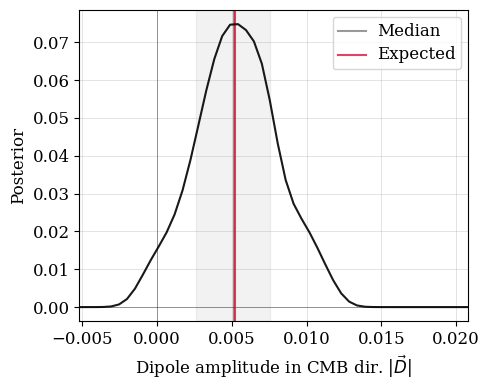

In [32]:
# ideal Quaia G20.0: kinematic dipole + shot noise (no excess power)
sample_name = 'quaia_G20.0'
cat_info = get_catalog_info(sample_name)
base_rate = cat_info['base_rate']
selfunc_str = cat_info['selfunc_str']
q, relamp, z, res, ax = get_abc_results_dipole_only(os.path.join(resdir,
                            f'ABC/fake_data/{selfunc_str}_base-rate-{base_rate:.4f}_dipamp-1.0x_excess-zero',
                                                                 f'dipole_only_nside{nside}_500mocks_15iters',
                                                                 f'QuantileEpsilon_alpha-0.5/results.npy'))